In [6]:
from utils import load_sparse_pauli_ops_from_pickle

In [7]:
loaded_ham = load_sparse_pauli_ops_from_pickle(f"linear_h_chains_bk_2q_reduced.json")
print(f"Precalculated molecules = {list(loaded_ham.keys())}")

Precalculated molecules = ['H2', 'H3', 'H4', 'H5', 'H6', 'H7', 'H8']


In [8]:
loaded_ham["H2"]

SparsePauliOp(['II', 'IZ', 'ZI', 'ZZ', 'XX'],
              coeffs=[-0.33995361+0.j,  0.39398368+0.j,  0.39398368+0.j,  0.01123659+0.j,
  0.18128881+0.j])

In [ ]:
import numpy as np
from time import time

computation_times = list()

for n_chain in [2, 3, 4, 5, 6, 7, 8]: # n_chain = 8 takes too long to compute (>30mins):
    ham = loaded_ham[f"H{n_chain}"]
    print(f"Calculating the ground state energy of H{n_chain}...")
    print(f"n_qubits = {ham.num_qubits}, n_terms = {len(ham)}")
    mat = np.array(ham)
    print("Dimension of the Hamiltonian matrix is ", mat.shape)
    t = time()
    eigenvalues, eigenvectors = np.linalg.eigh(mat)

    computation_time = time() - t
    computation_times.append(computation_time)

    print("The ground state energy is ", min(eigenvalues), "hartrees")
    print("Computation time: ", computation_time, "seconds")
    print("")

Calculating the ground state energy of H2...
n_qubits = 2, n_terms = 5
Dimension of the Hamiltonian matrix is  (4, 4)
The ground state energy is  -1.137270174660903 hartrees
Computation time:  0.024614572525024414 seconds

Calculating the ground state energy of H3...
n_qubits = 4, n_terms = 52
Dimension of the Hamiltonian matrix is  (16, 16)
The ground state energy is  -1.5269470051364777 hartrees
Computation time:  0.0 seconds

Calculating the ground state energy of H4...
n_qubits = 6, n_terms = 165
Dimension of the Hamiltonian matrix is  (64, 64)
The ground state energy is  -2.13979964472261 hartrees
Computation time:  0.0019655227661132812 seconds

Calculating the ground state energy of H5...
n_qubits = 8, n_terms = 444
Dimension of the Hamiltonian matrix is  (256, 256)
The ground state energy is  -2.5582083207653468 hartrees
Computation time:  0.09498453140258789 seconds

Calculating the ground state energy of H6...
n_qubits = 10, n_terms = 919
Dimension of the Hamiltonian matrix i

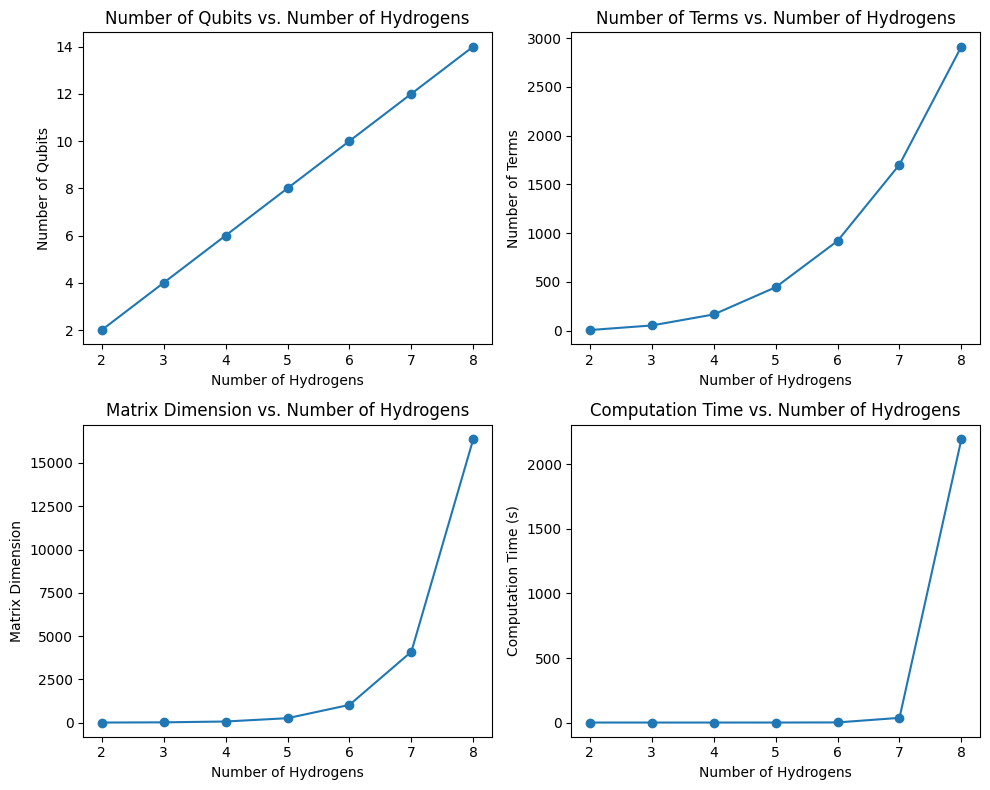

In [11]:
import matplotlib.pyplot as plt

# Collect data for each number of hydrogens (n_chain from 2 to 7)
n_chains = list(range(2, 9))
n_qubits_list = [loaded_ham[f"H{n}"].num_qubits for n in n_chains]
n_terms_list = [len(loaded_ham[f"H{n}"]) for n in n_chains]
dimensions_list = [np.array(loaded_ham[f"H{n}"]).shape[0] for n in n_chains]
times_list = computation_times  # Already computed in the previous cell

# Create subplots
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

# Plot number of qubits
axs[0, 0].plot(n_chains, n_qubits_list, marker='o')
axs[0, 0].set_title('Number of Qubits vs. Number of Hydrogens')
axs[0, 0].set_xlabel('Number of Hydrogens')
axs[0, 0].set_ylabel('Number of Qubits')

# Plot number of terms
axs[0, 1].plot(n_chains, n_terms_list, marker='o')
axs[0, 1].set_title('Number of Terms vs. Number of Hydrogens')
axs[0, 1].set_xlabel('Number of Hydrogens')
axs[0, 1].set_ylabel('Number of Terms')

# Plot matrix dimension
axs[1, 0].plot(n_chains, dimensions_list, marker='o')
axs[1, 0].set_title('Matrix Dimension vs. Number of Hydrogens')
axs[1, 0].set_xlabel('Number of Hydrogens')
axs[1, 0].set_ylabel('Matrix Dimension')

# Plot computation time
axs[1, 1].plot(n_chains, times_list, marker='o')
axs[1, 1].set_title('Computation Time vs. Number of Hydrogens')
axs[1, 1].set_xlabel('Number of Hydrogens')
axs[1, 1].set_ylabel('Computation Time (s)')

plt.tight_layout()
plt.show()